# SHAP Values 

**SHAP (SHapley Additive exPlanations)** is a method used to explain how each feature contributes to a model’s prediction.

It is based on game theory, where each feature is treated like a "player" contributing to the final prediction. SHAP assigns a value to each feature showing how much it increases or decreases the prediction.

#### Key Points:
- Explains **individual predictions** (local interpretability)
- Shows **feature impact clearly** (positive or negative effect)
- Works with many ML models (tree-based, deep learning, etc.)

#### Why it is useful:
- Helps understand **why a model made a decision**
- Builds **trust** with stakeholders
- Supports **Explainable AI (XAI)** and business insights

> *In simple terms, SHAP tells you: "How much did each feature contribute to this specific prediction?"*

### Import libraries

In [1]:
import shap
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

### Load dataset
***Here, the california housing dataset from scikit-learn is used***

In [2]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

### Train-test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Train model

In [4]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Create SHAP explainer

In [5]:
explainer = shap.Explainer(model, X_train)

### Calculate SHAP values

In [6]:
shap_values = explainer(X_test, check_additivity=False)

100%|===================| 4116/4128 [06:08<00:01]        

### Summary plot (feature importance)

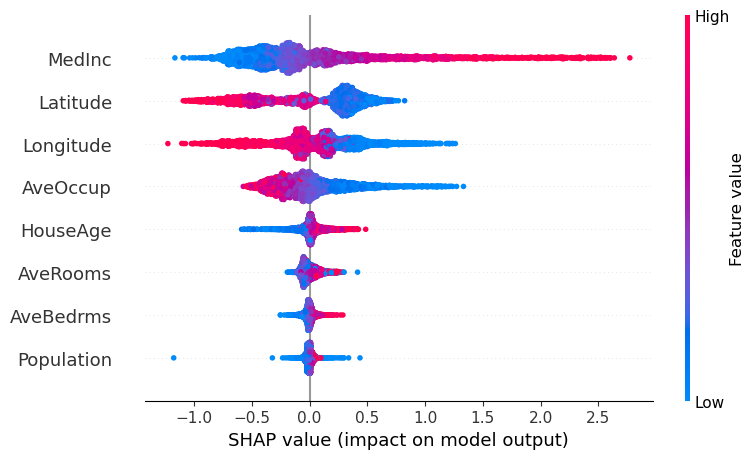

In [7]:
shap.summary_plot(shap_values, X_test)

### Force plot for one prediction

In [8]:
shap.initjs()
shap.plots.force(shap_values[0])